# Semantic Stability Experiment

This notebook evaluates the stability of cluster semantic structures across different UMAP and clustering parameters. 
It uses the Hungarian algorithm to match clusters between different setups based on their top keywords similarity.

In [1]:
import sys
import pandas as pd
import json
import numpy as np
sys.path.append("..")

In [2]:
from src.experiments.semantic_stability import SemanticStabilityExperiment
from src.visualization.stability_plots import StabilityPlotter

## Run Stability Analysis

This will compare all pairs of semantic evaluation results for each clustering method.

In [3]:
experiment = SemanticStabilityExperiment()
results = experiment.run()

2026-05-19 14:41:57,880 - INFO - Starting Semantic Stability Experiment
2026-05-19 14:41:57,885 - INFO - Processing method: agglomerative
Comparing agglomerative: 100%|██████████| 48/48 [00:01<00:00, 37.44it/s]
2026-05-19 14:41:59,257 - INFO - Saved results for agglomerative
2026-05-19 14:41:59,257 - INFO - Processing method: dbscan
Comparing dbscan: 100%|██████████| 48/48 [00:12<00:00,  3.85it/s]
2026-05-19 14:42:11,746 - INFO - Saved results for dbscan
2026-05-19 14:42:11,746 - INFO - Processing method: hdbscan
Comparing hdbscan: 100%|██████████| 24/24 [00:00<00:00, 43.76it/s]
2026-05-19 14:42:12,316 - INFO - Saved results for hdbscan
2026-05-19 14:42:12,316 - INFO - Processing method: kmeans
Comparing kmeans: 100%|██████████| 24/24 [00:00<00:00, 72.84it/s]
2026-05-19 14:42:12,674 - INFO - Saved results for kmeans
2026-05-19 14:42:12,708 - INFO - Semantic Stability Experiment Complete


## Generate Heatmaps

Visualize the similarity matrices as heatmaps to identify stable parameter regions.

{'agglomerative': {'similarity_plot': WindowsPath('C:/Users/Acer/OneDrive/Desktop/work_folder/science/utm_conference_2026/umap-spurious-clusters/experiments/semantic_stability/figures/agglomerative_similarity_clustermap.png'),
  'coverage_plot': WindowsPath('C:/Users/Acer/OneDrive/Desktop/work_folder/science/utm_conference_2026/umap-spurious-clusters/experiments/semantic_stability/figures/agglomerative_coverage_clustermap.png')},
 'dbscan': {'similarity_plot': WindowsPath('C:/Users/Acer/OneDrive/Desktop/work_folder/science/utm_conference_2026/umap-spurious-clusters/experiments/semantic_stability/figures/dbscan_similarity_clustermap.png'),
  'coverage_plot': WindowsPath('C:/Users/Acer/OneDrive/Desktop/work_folder/science/utm_conference_2026/umap-spurious-clusters/experiments/semantic_stability/figures/dbscan_coverage_clustermap.png')},
 'hdbscan': {'similarity_plot': WindowsPath('C:/Users/Acer/OneDrive/Desktop/work_folder/science/utm_conference_2026/umap-spurious-clusters/experiments/se

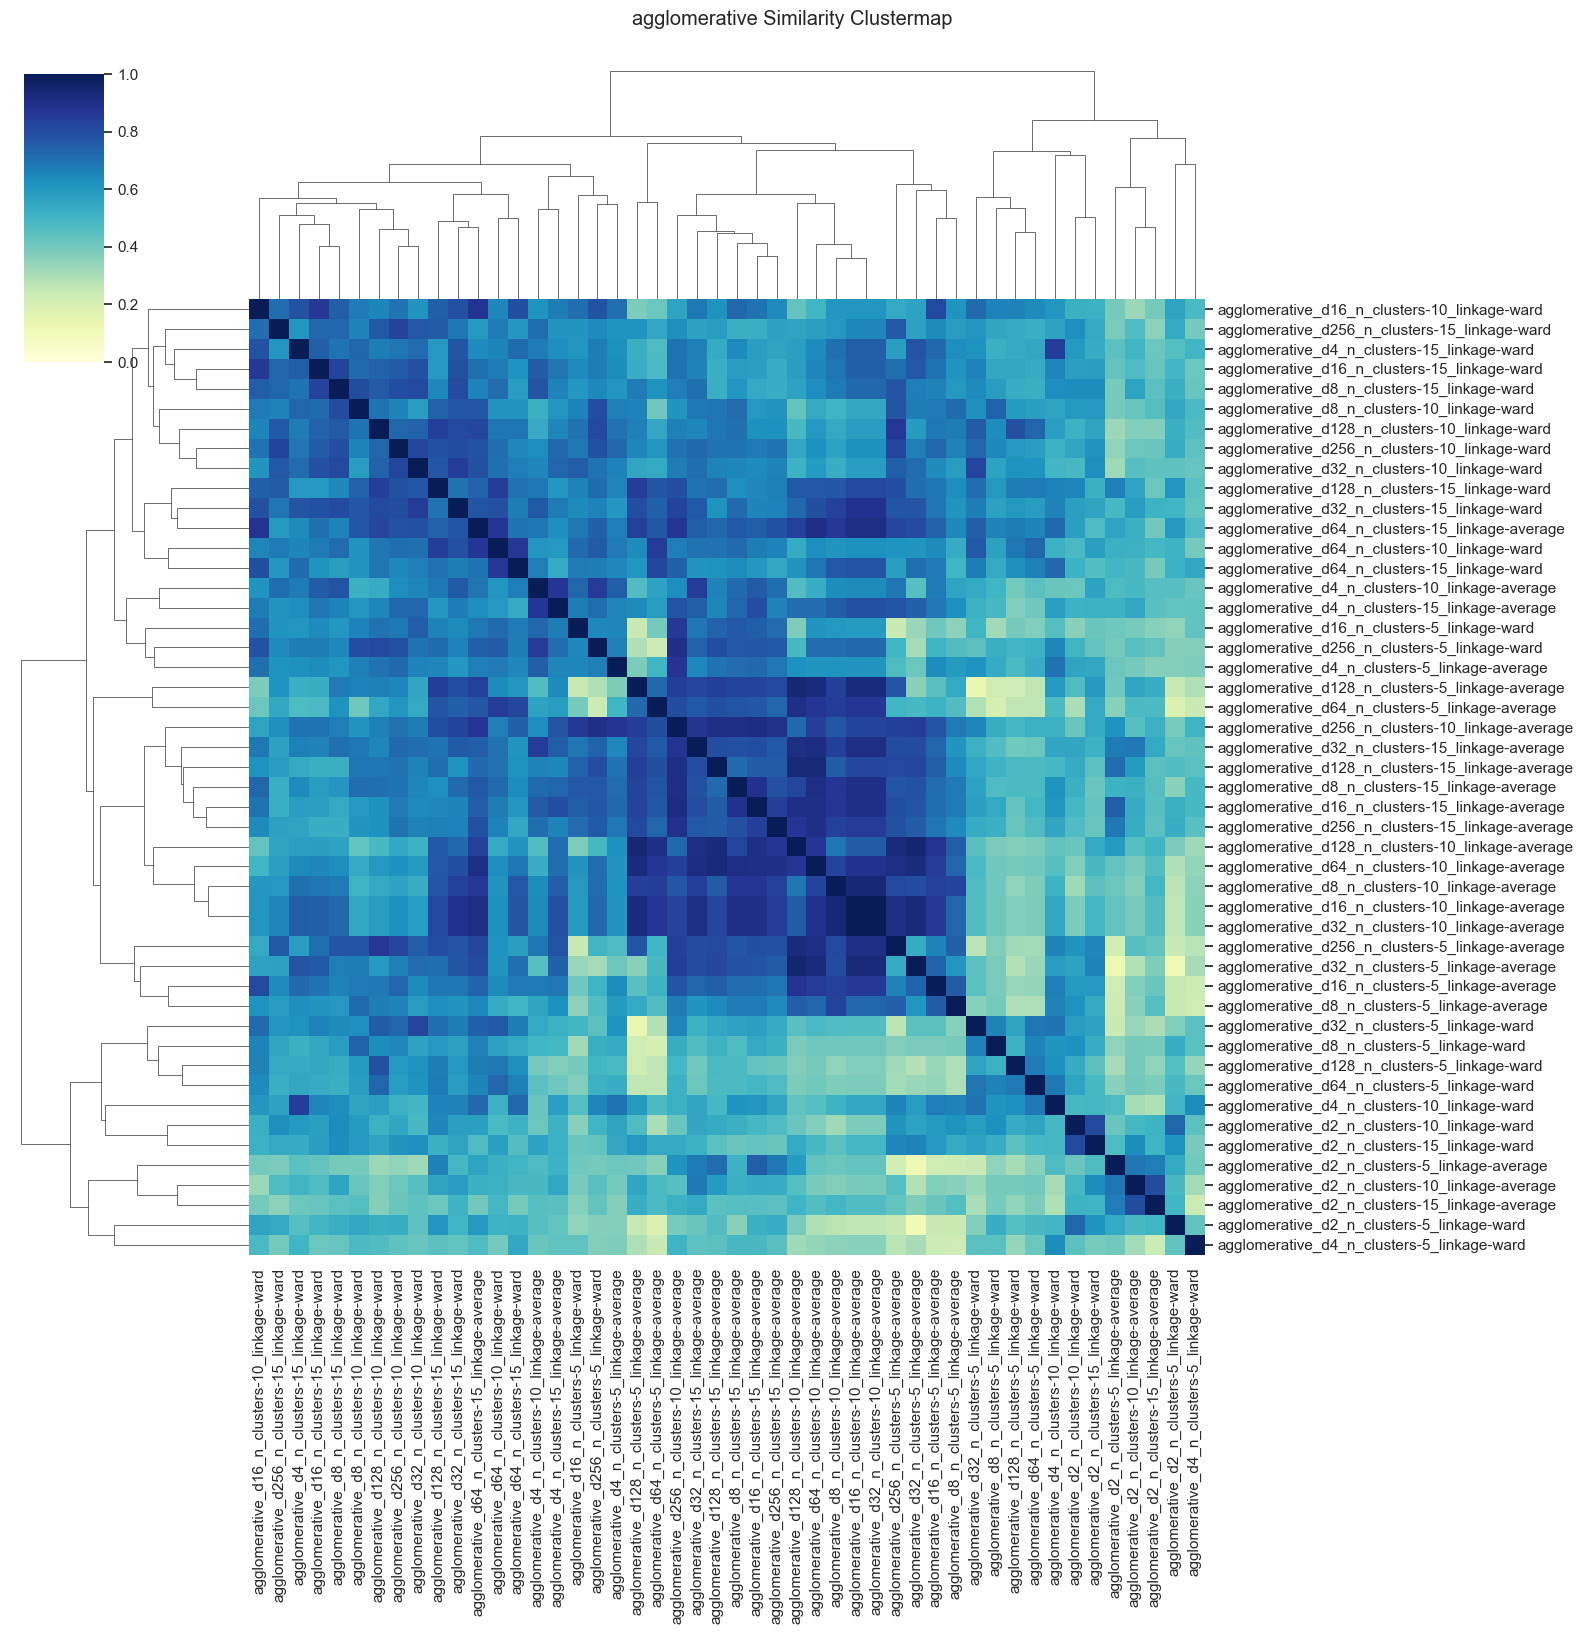

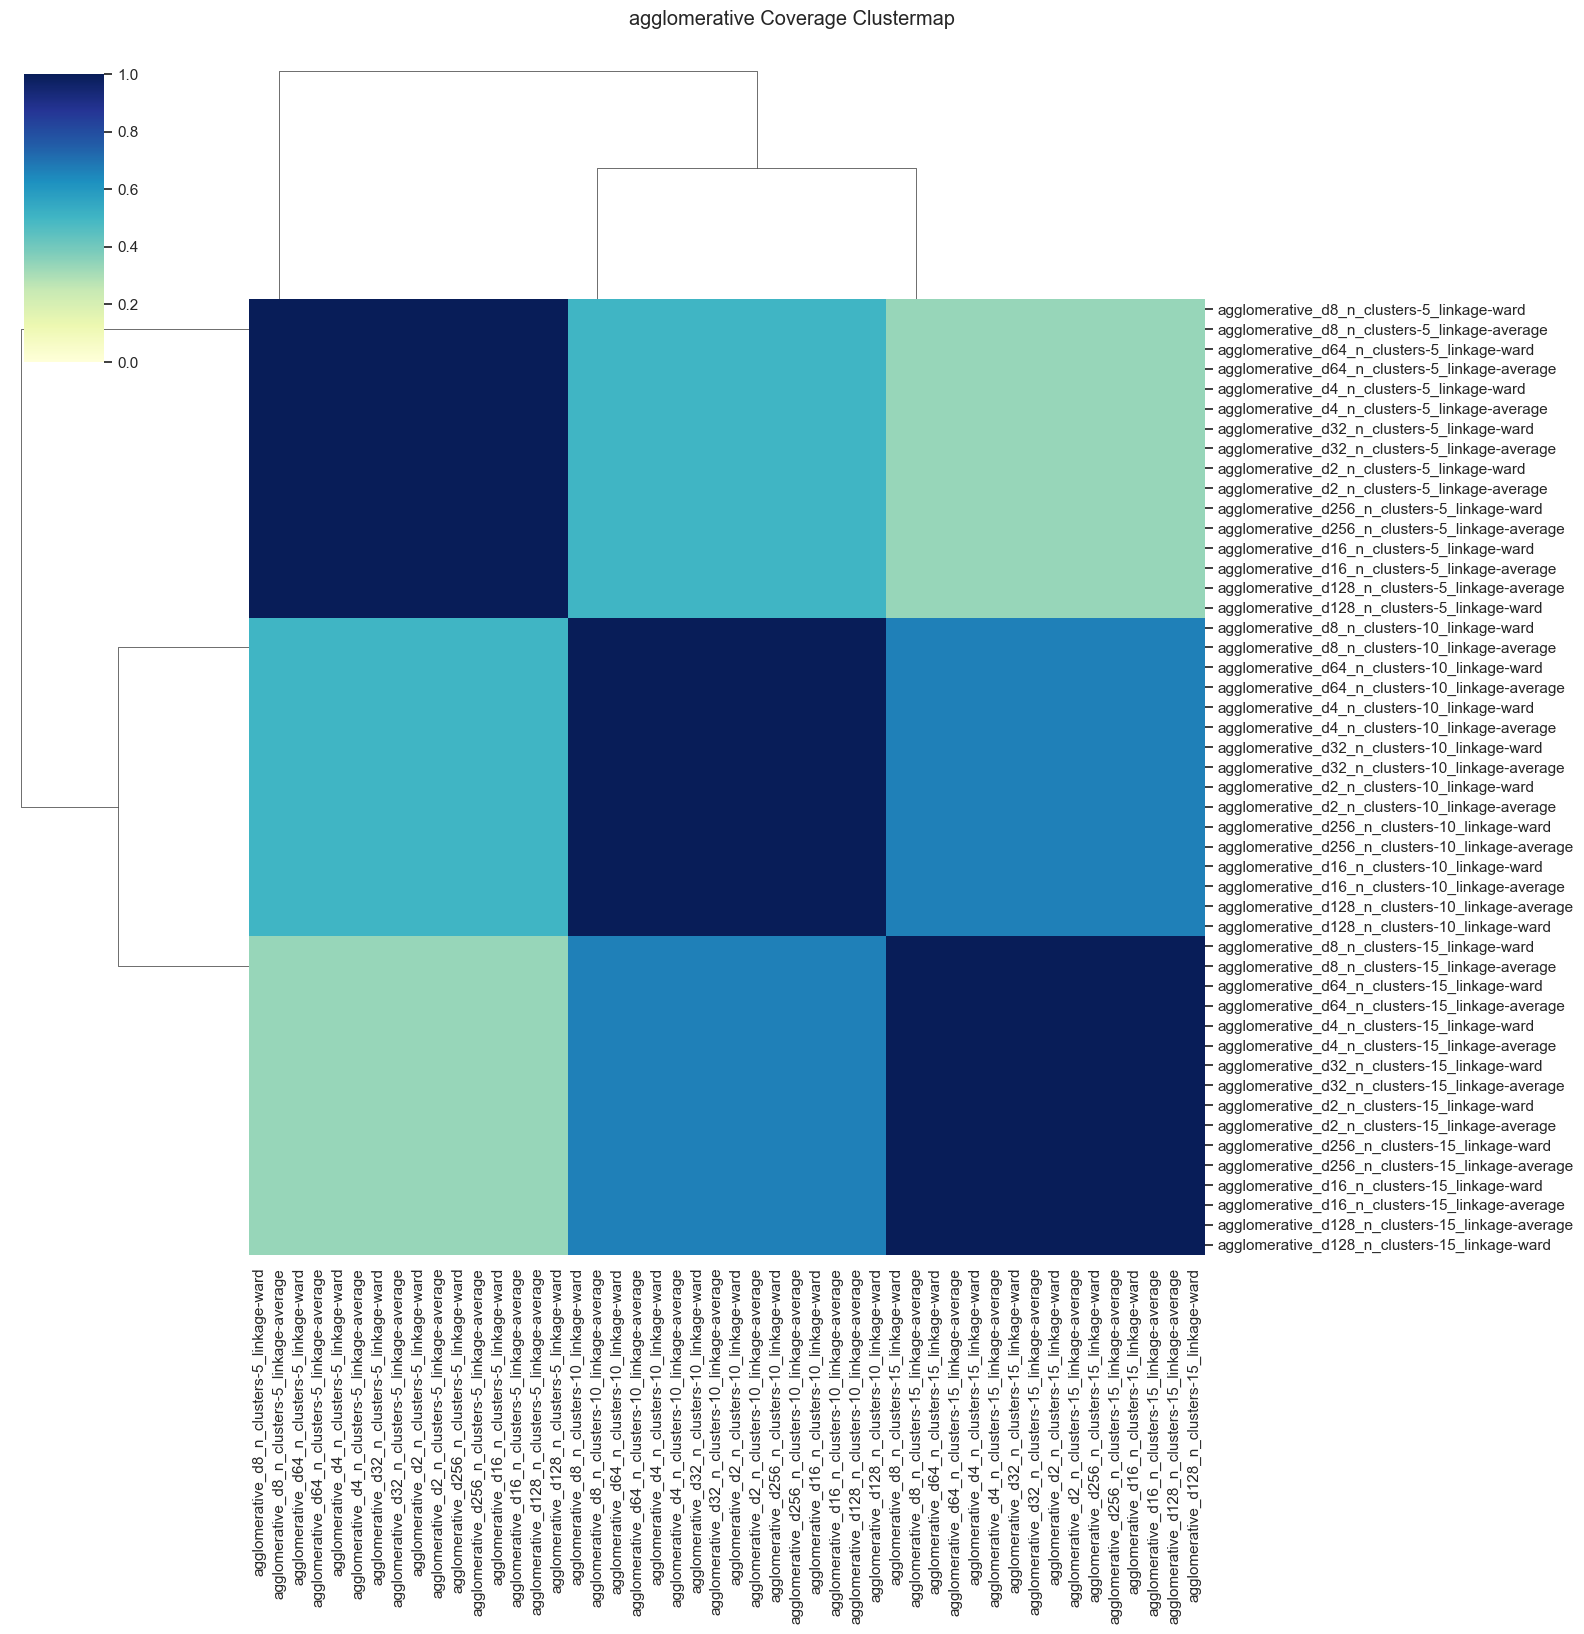

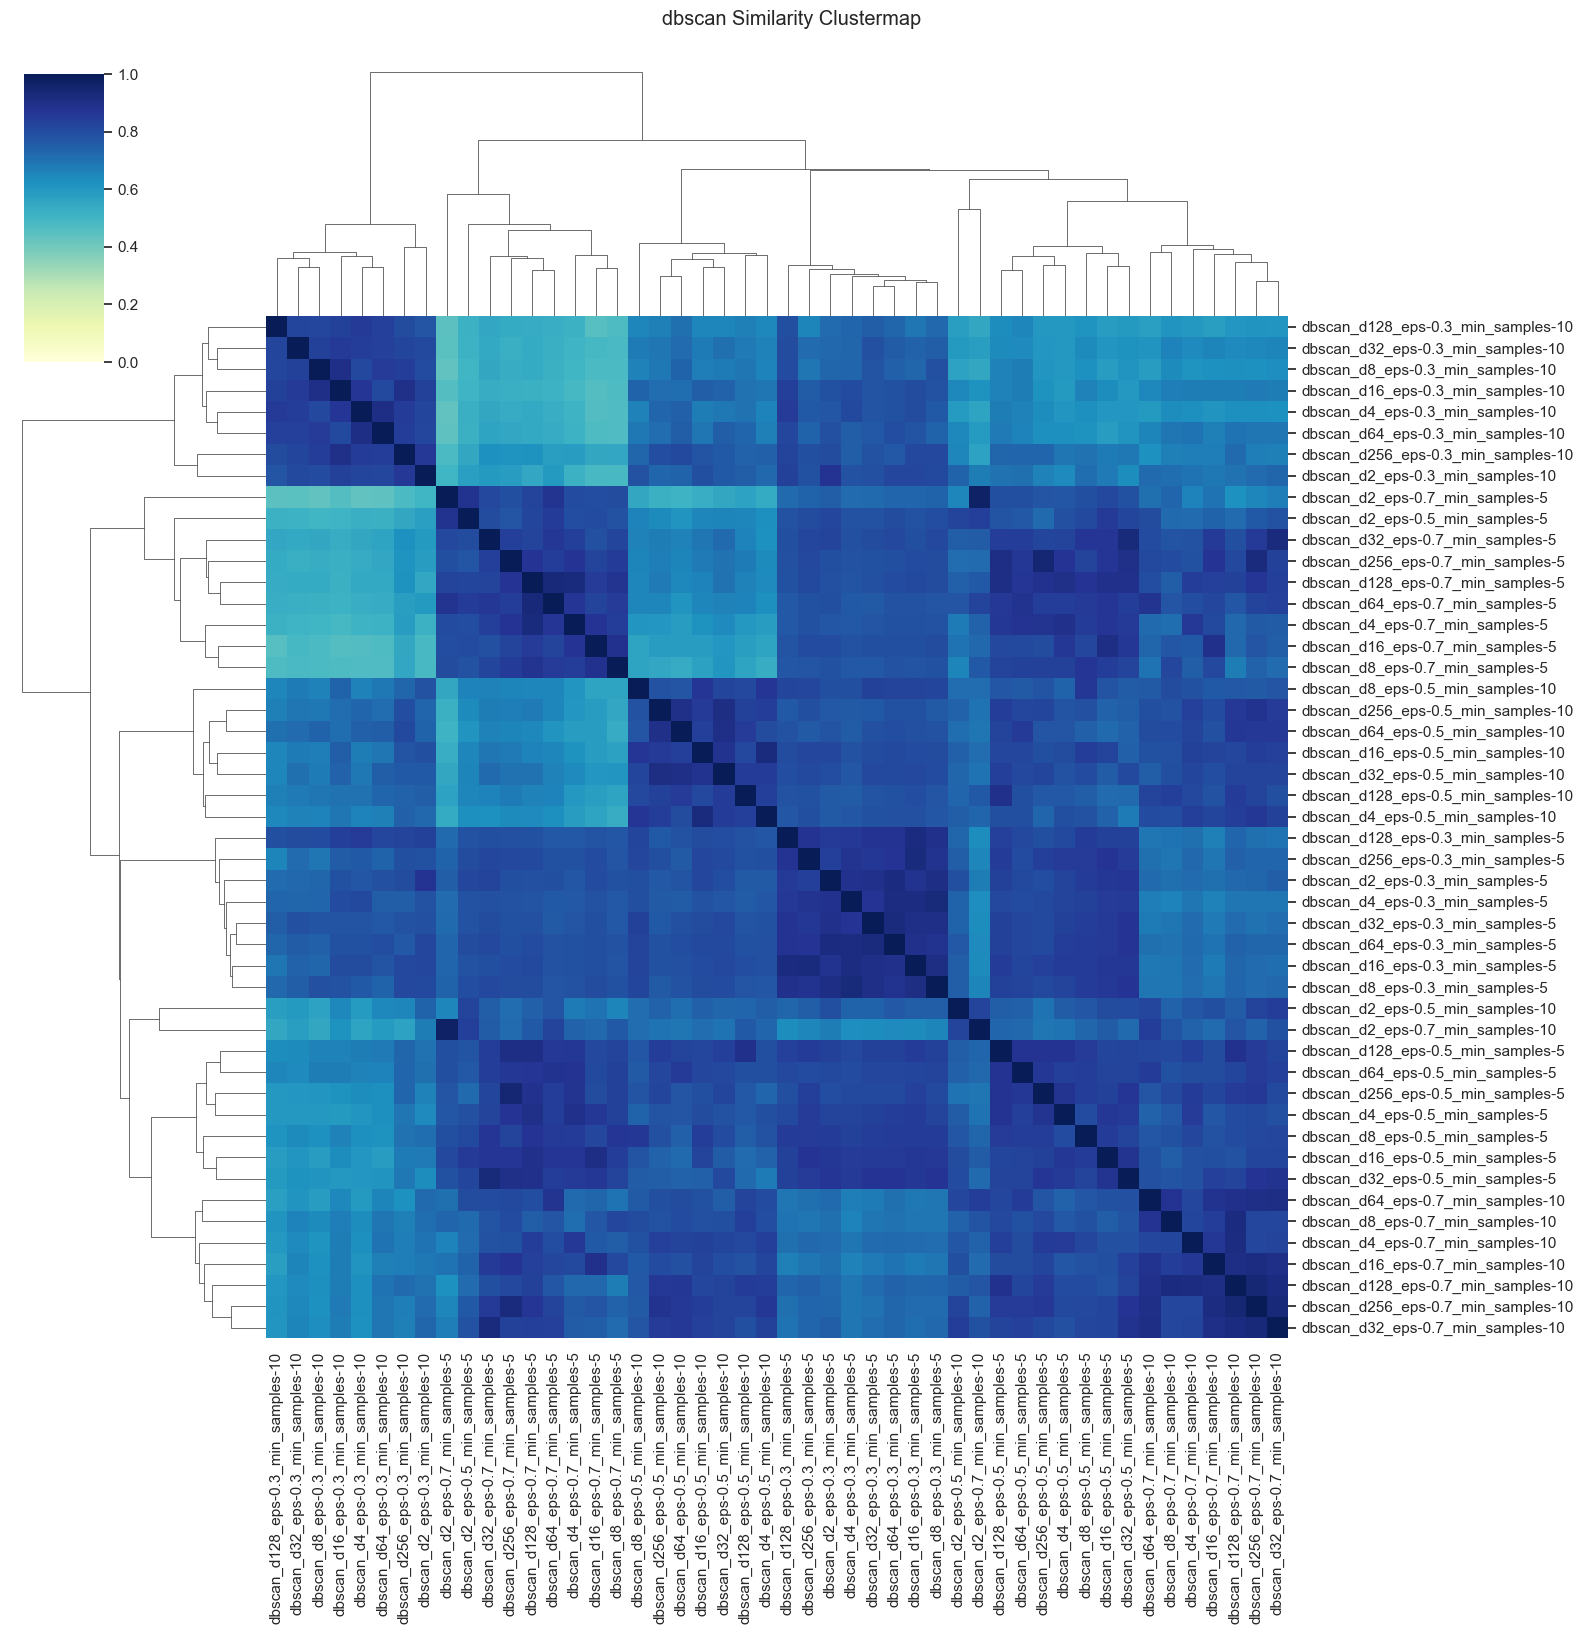

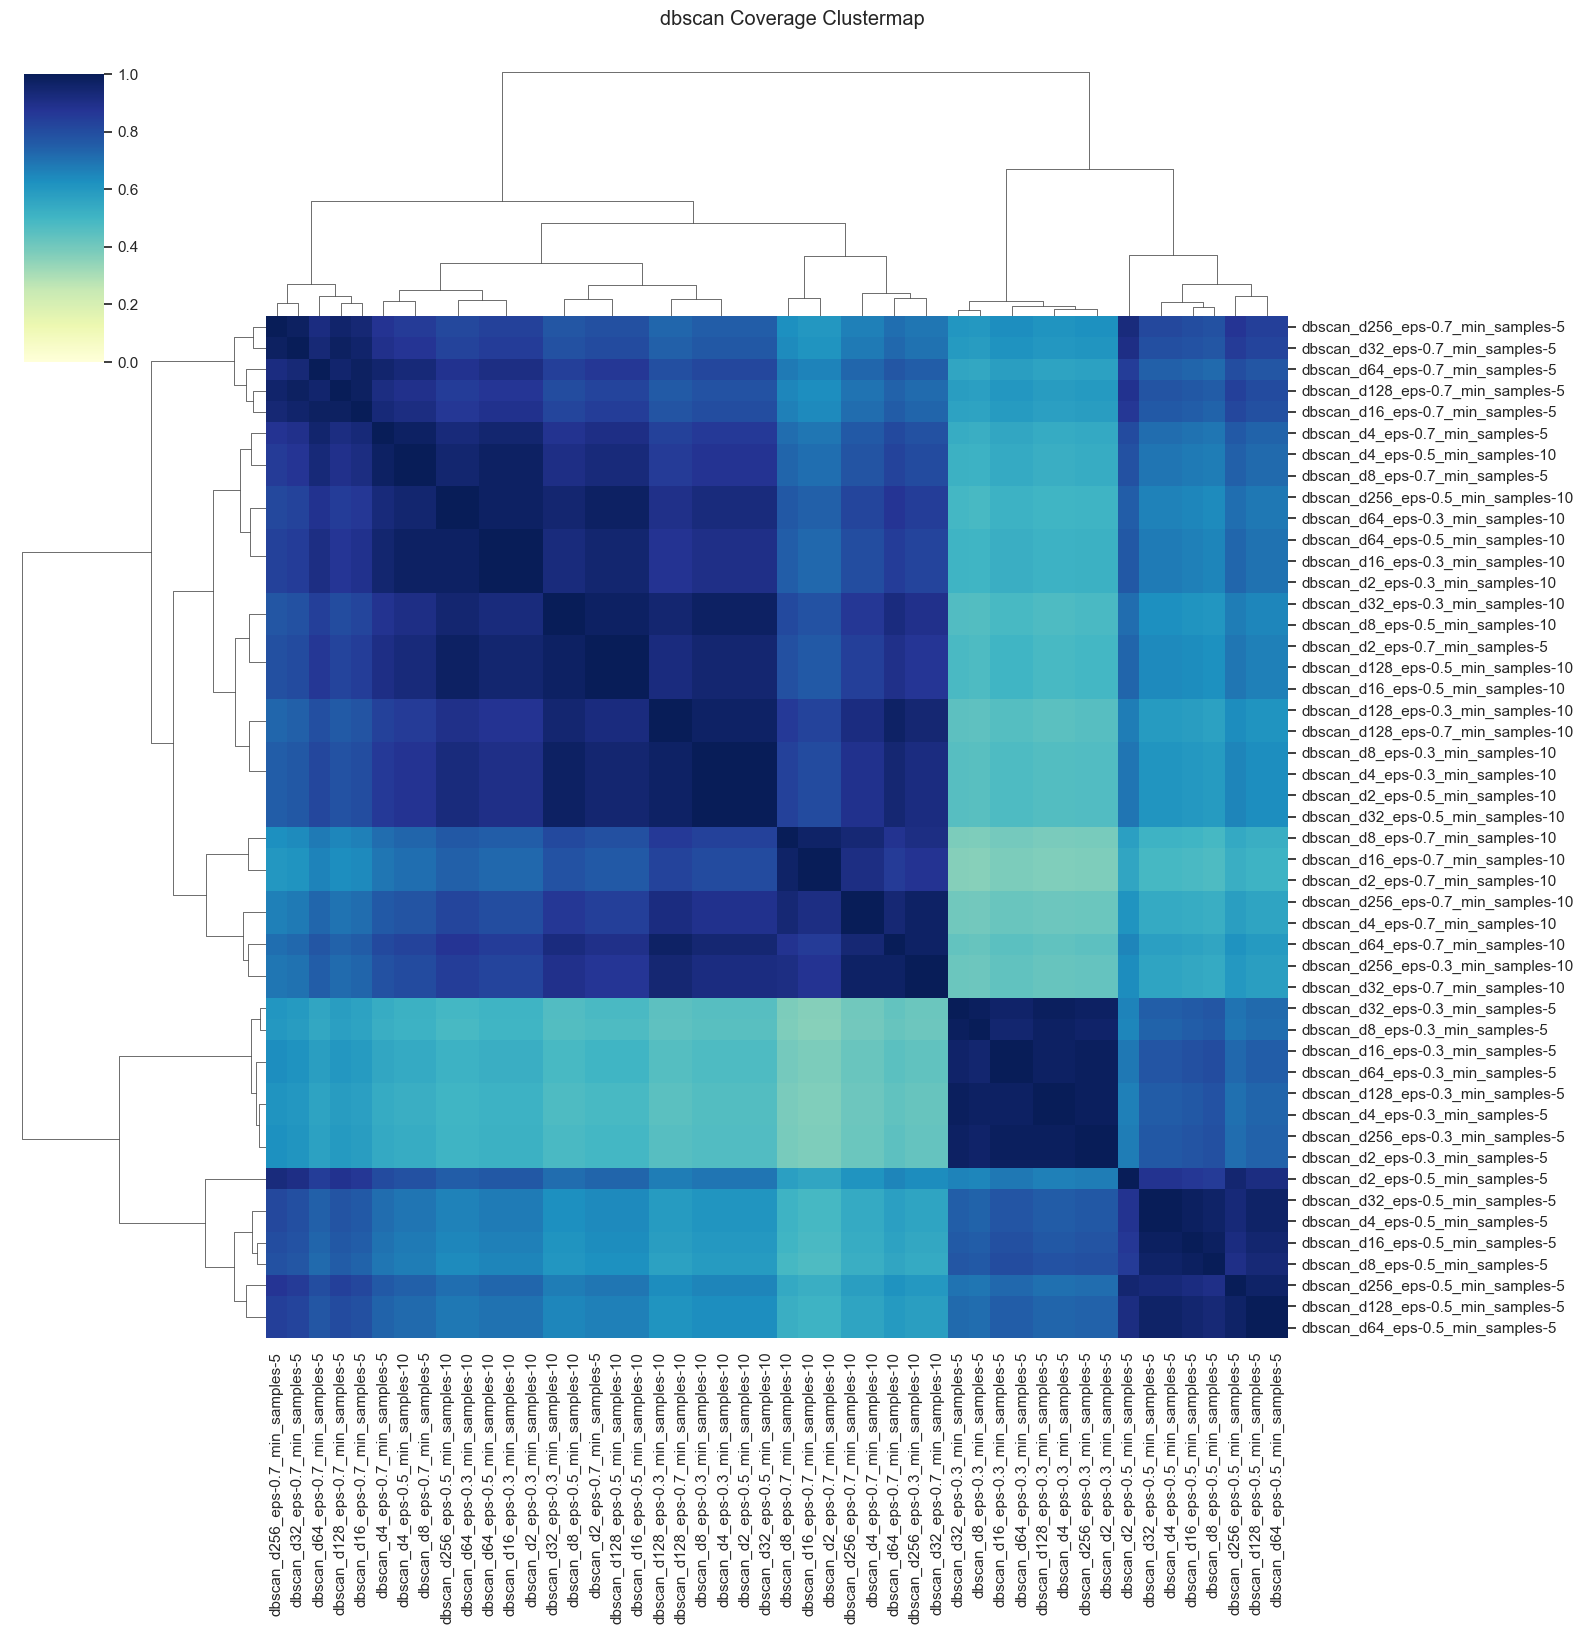

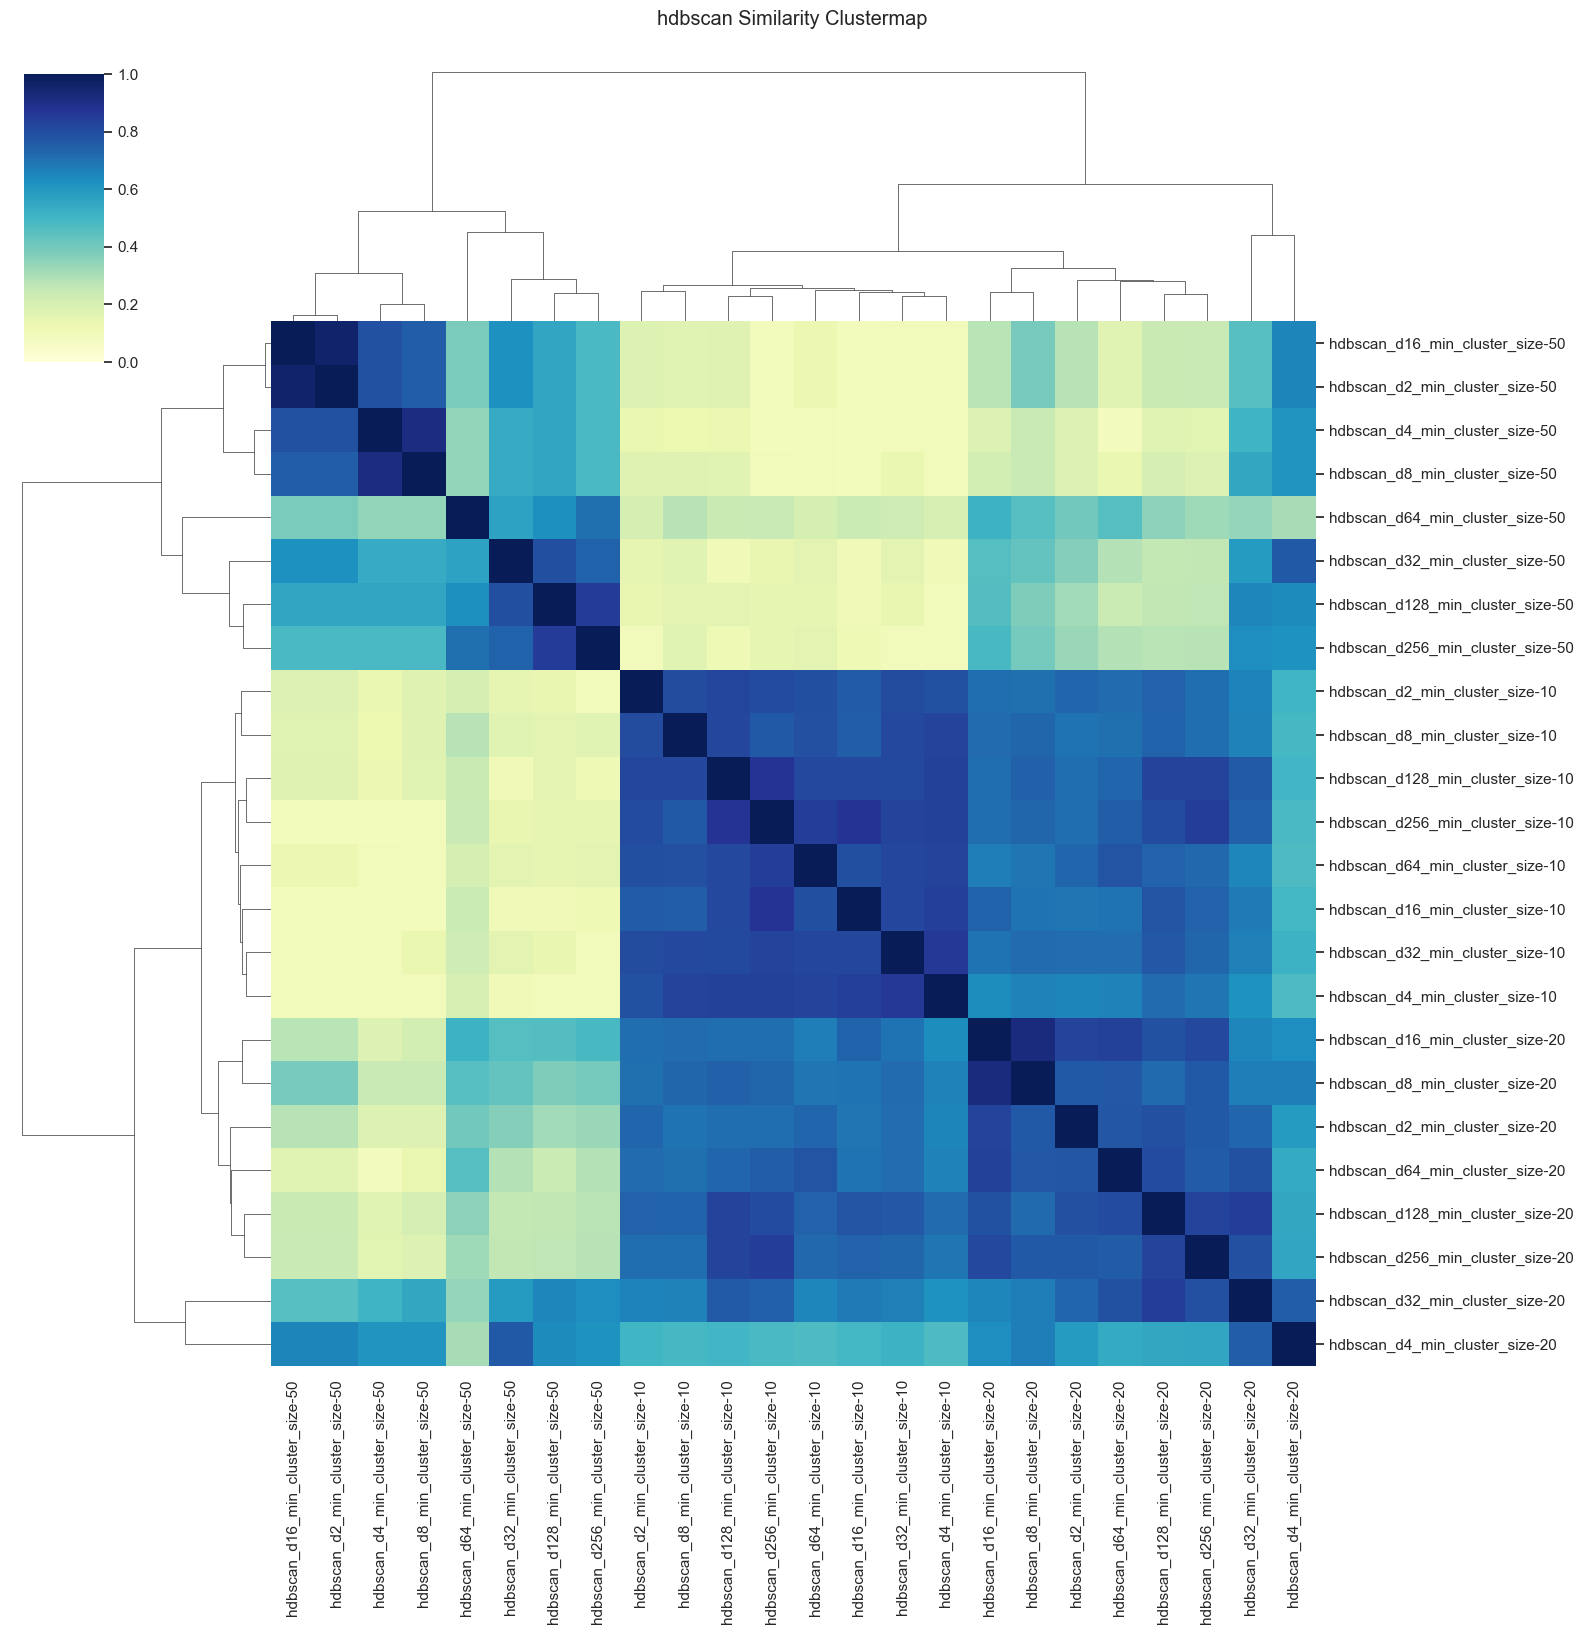

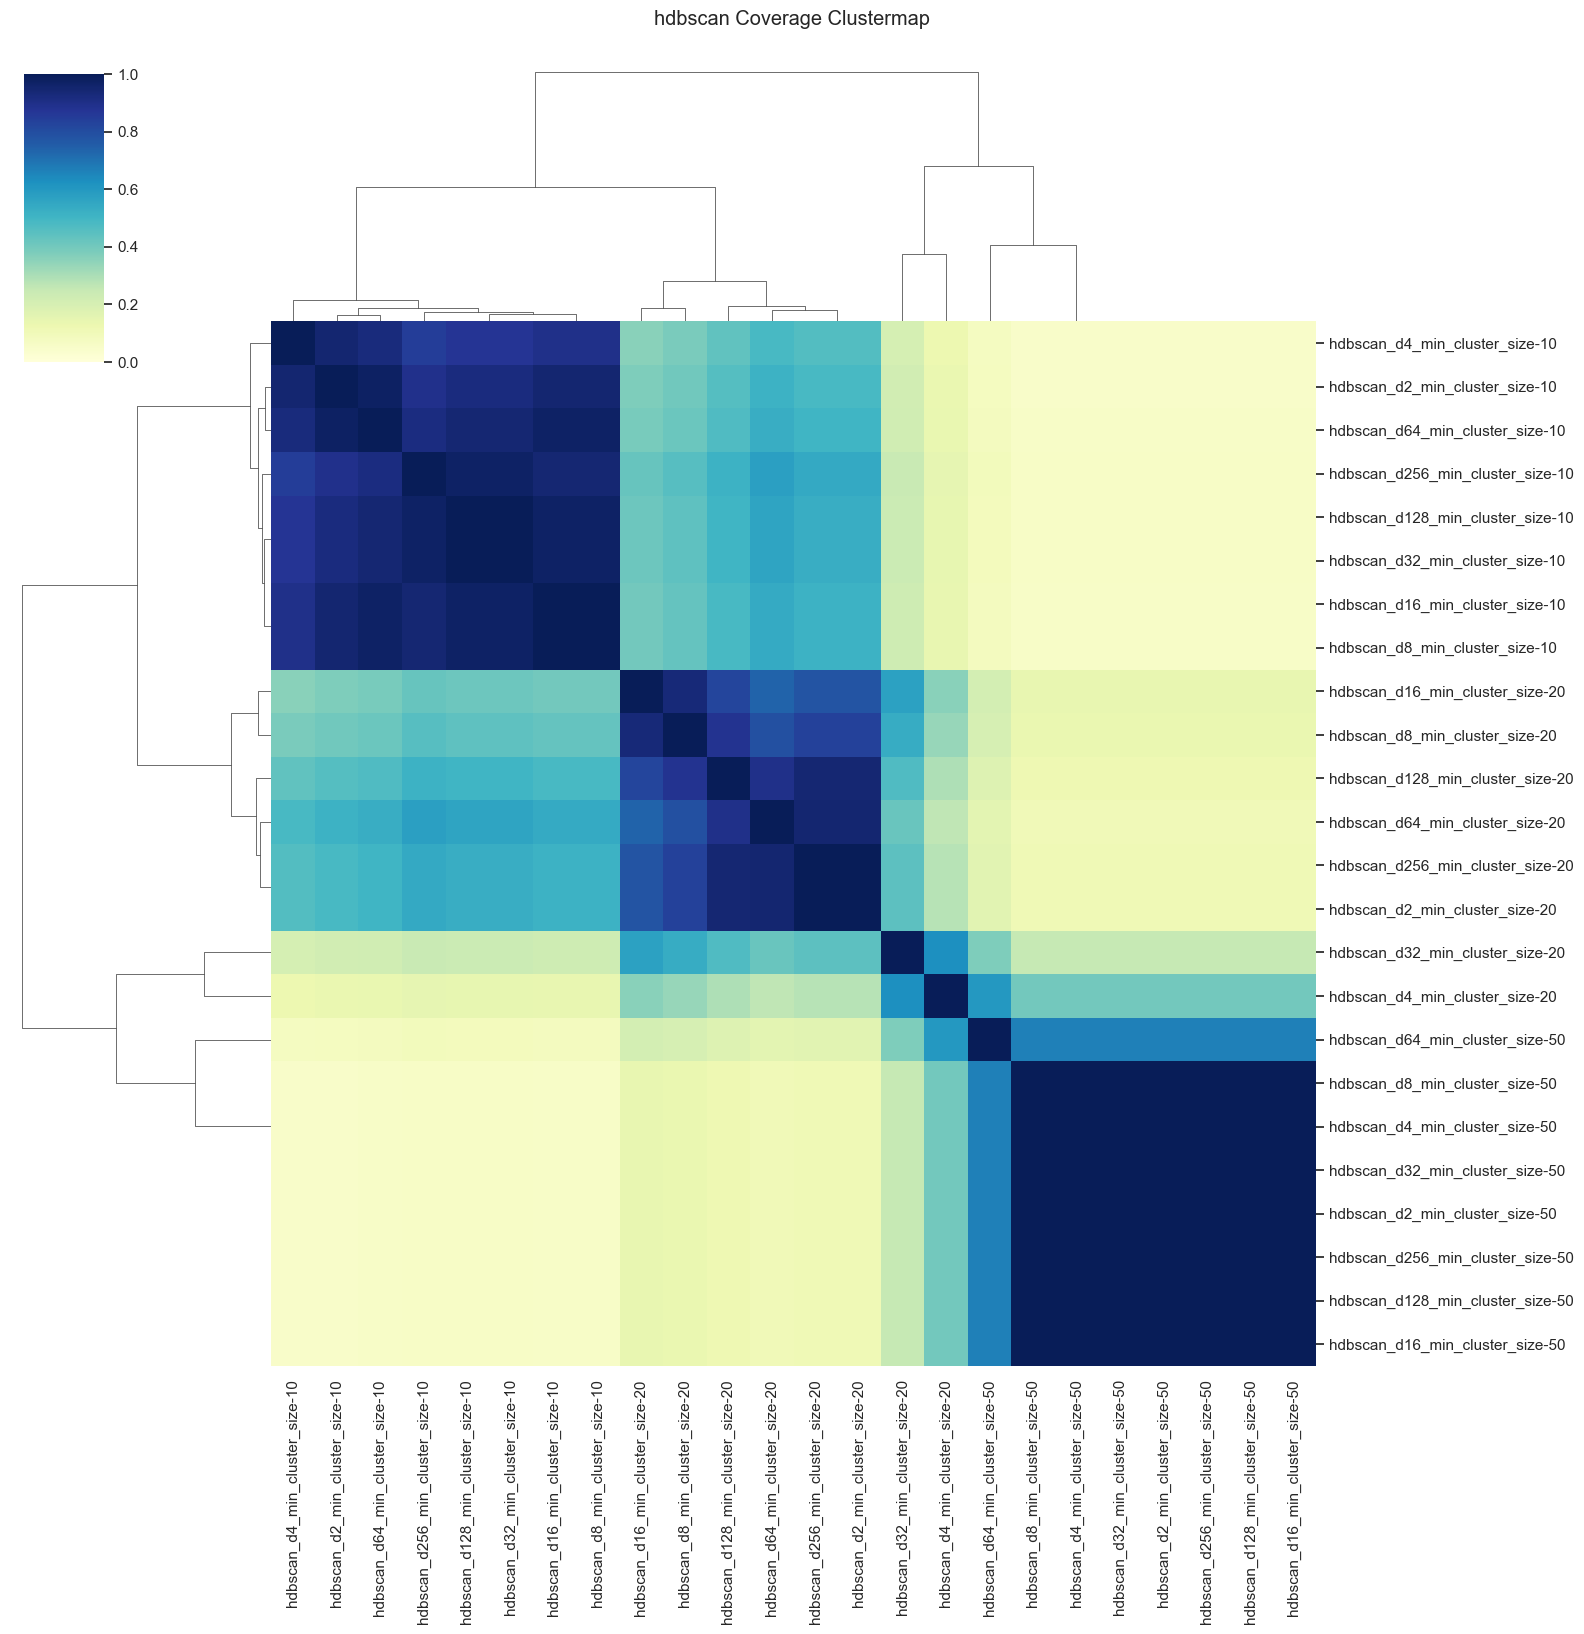

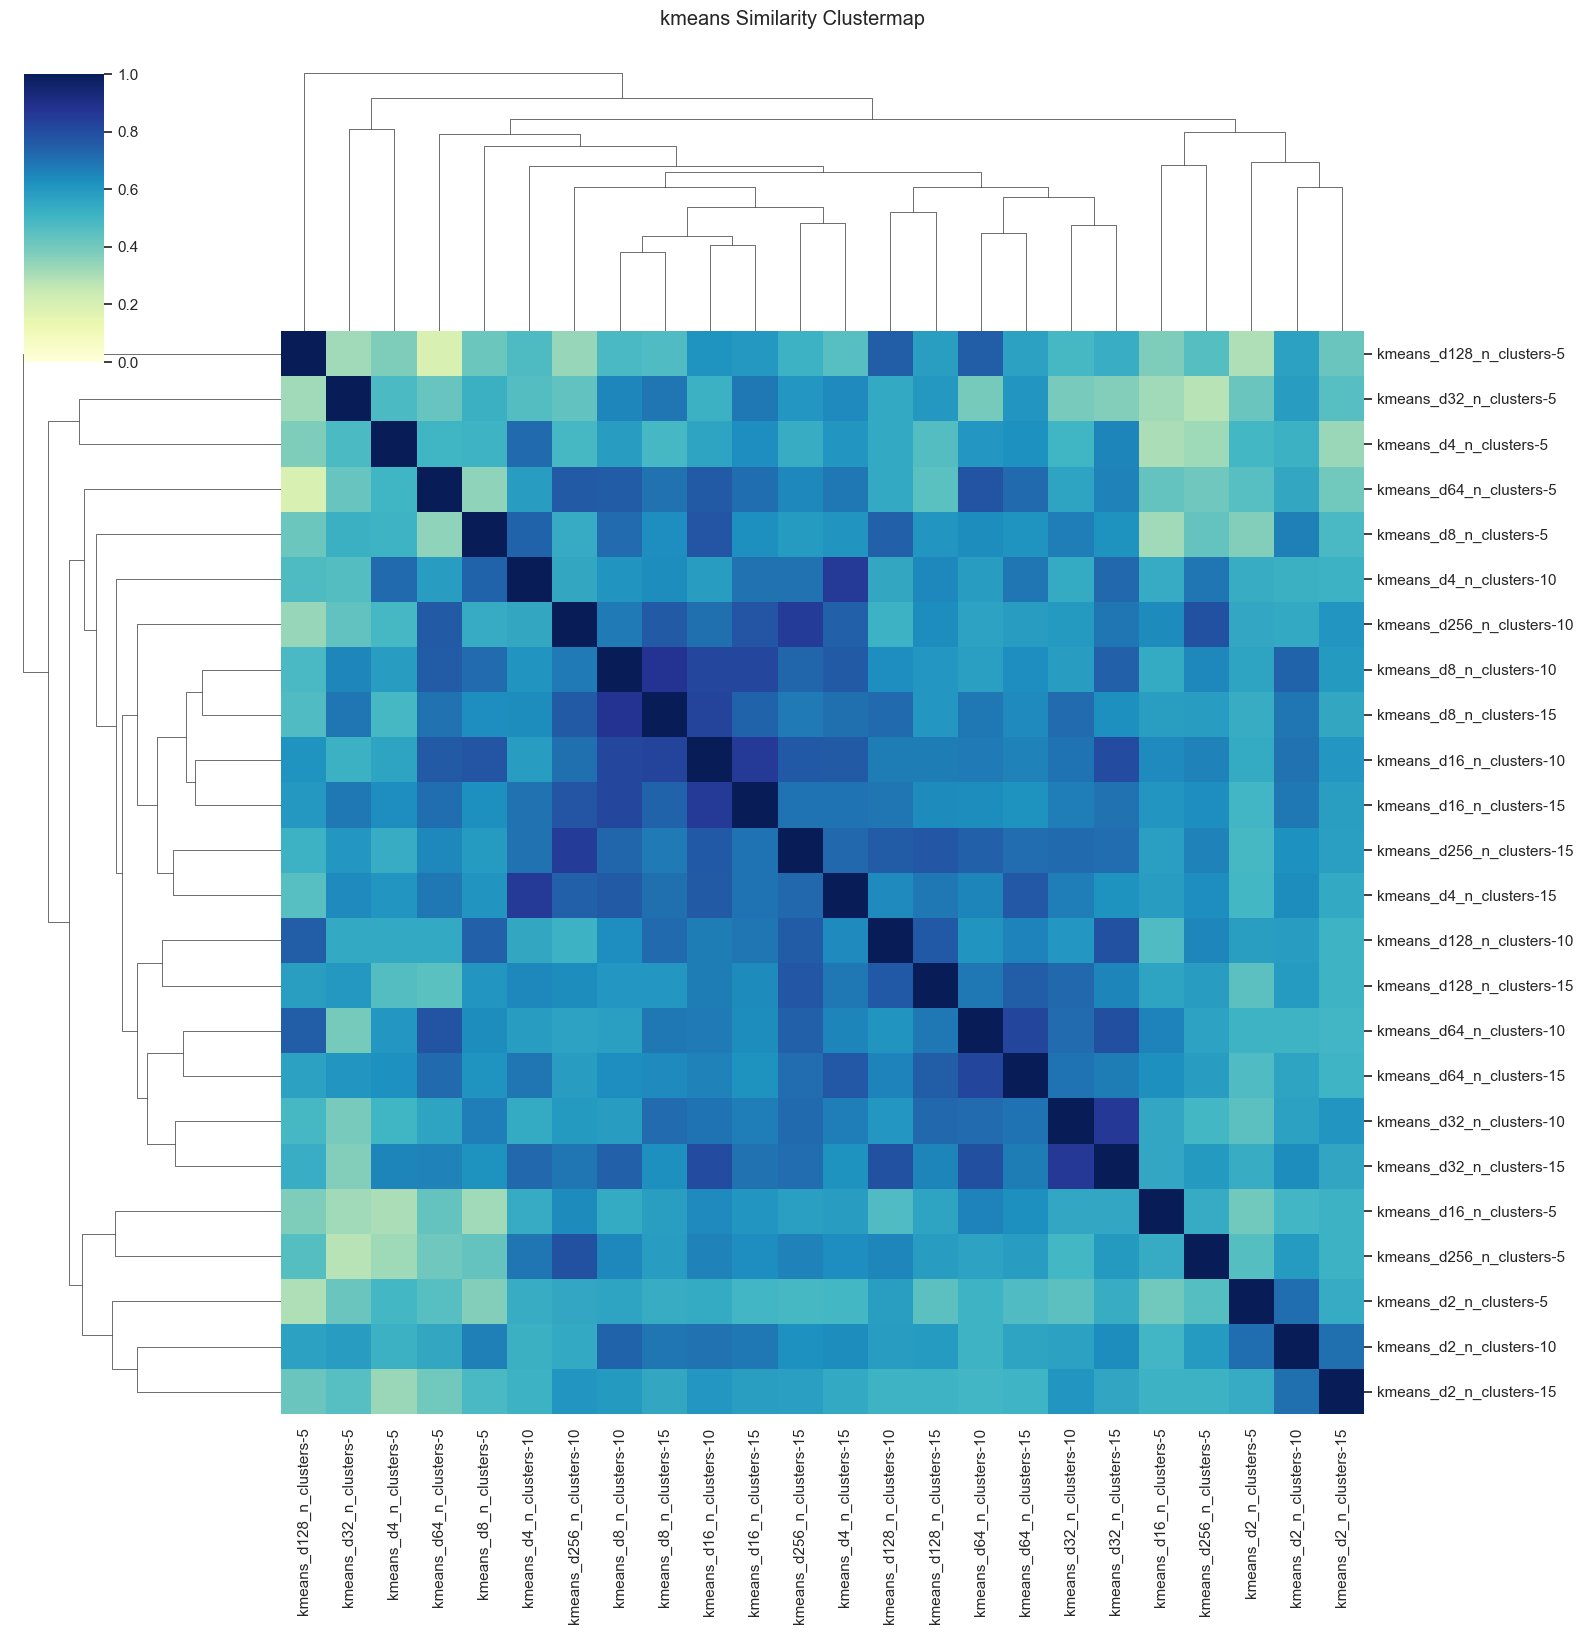

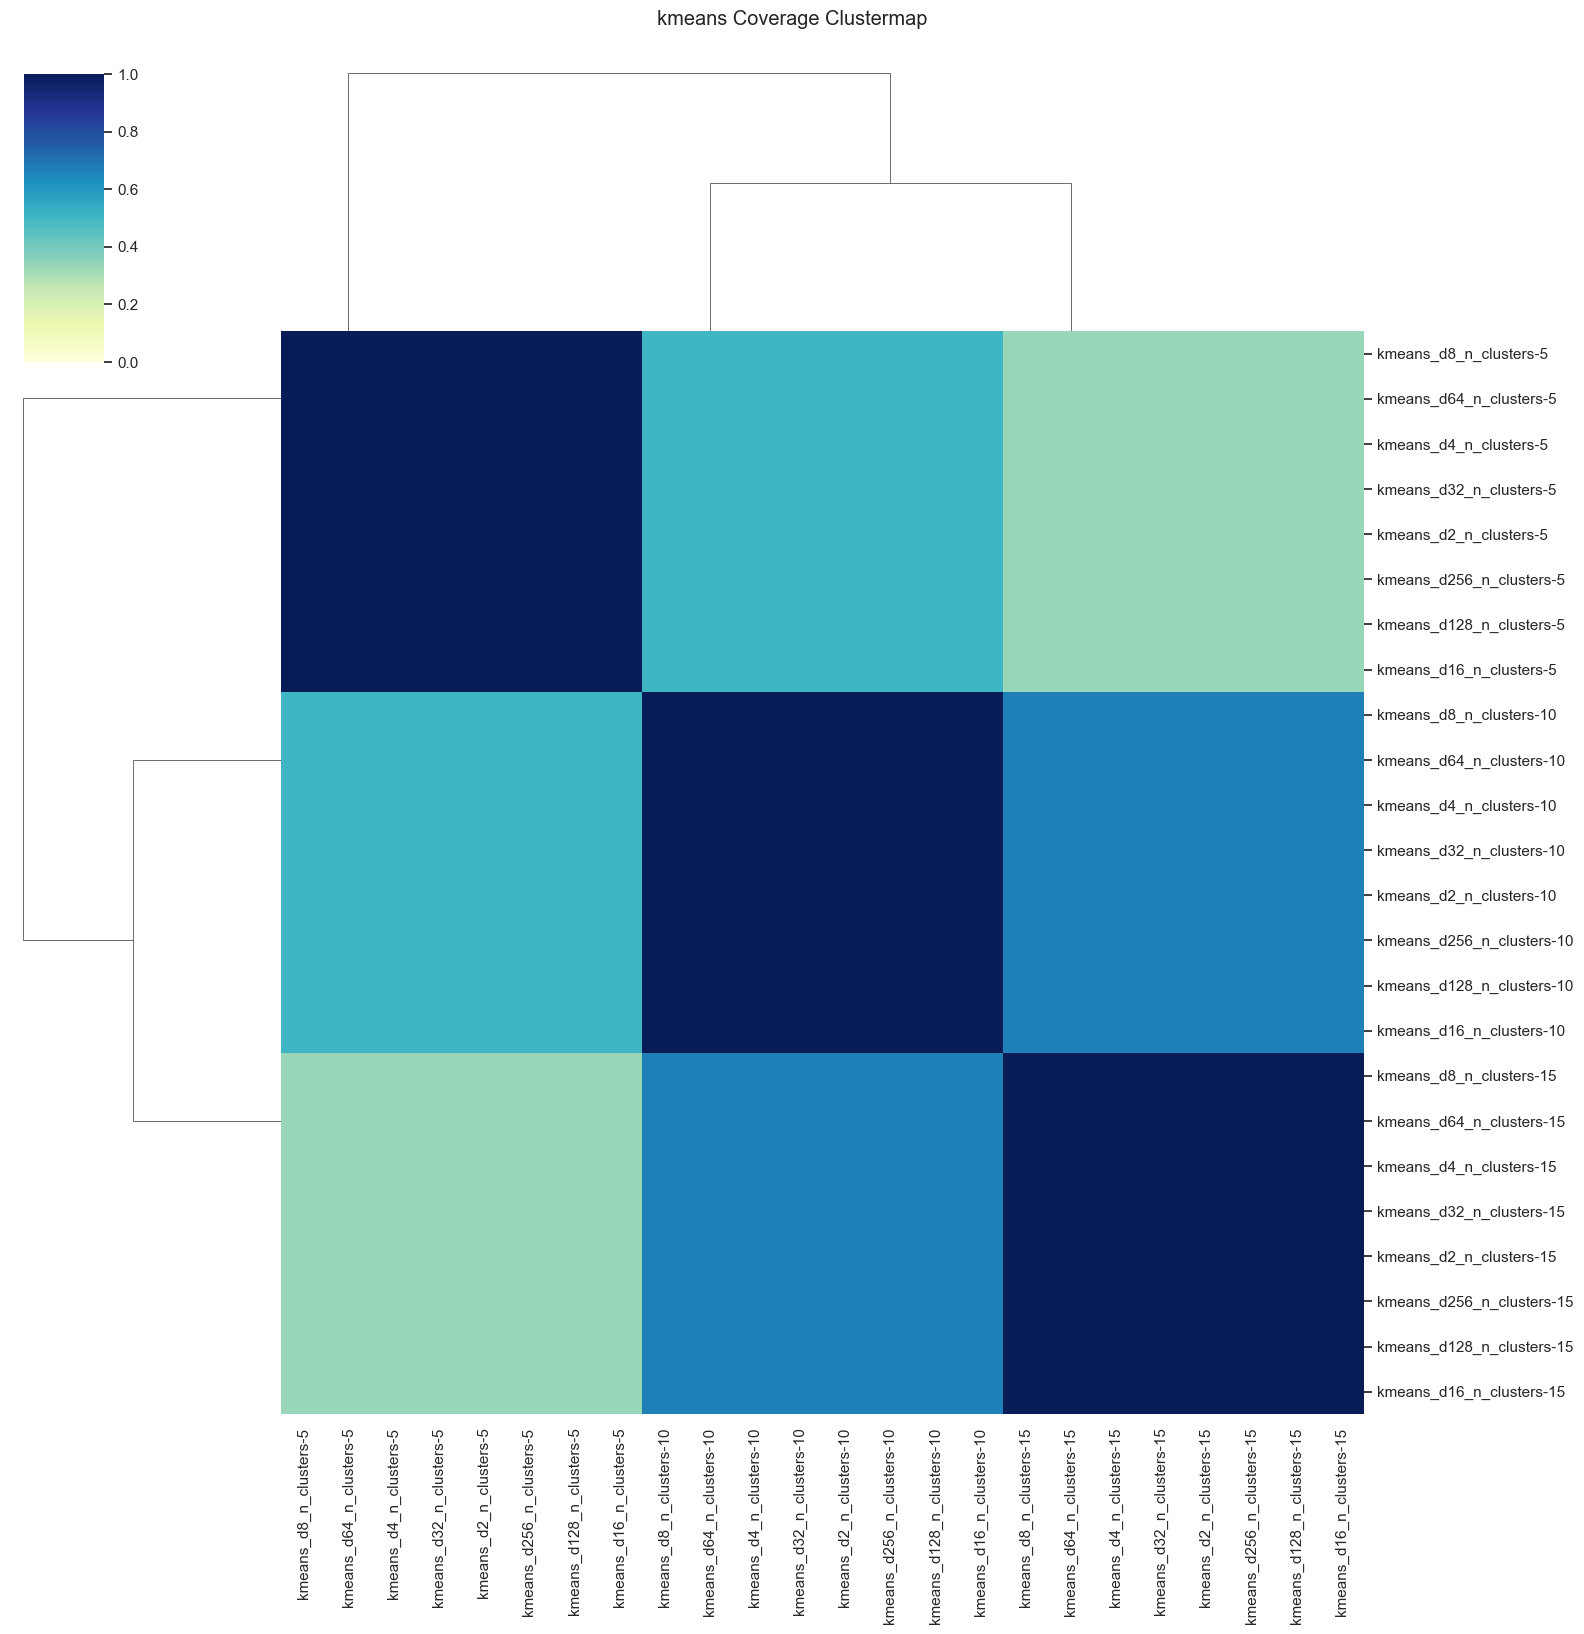

In [4]:
plotter = StabilityPlotter()
plotter.plot_all_heatmaps(results)

## Analyze Summary

Load the summary and look at average stability per method.

In [11]:
with open("../experiments/semantic_stability/results/summary.json", "r") as f:
    summary = json.load(f)

for method, data in summary.items():
    matrix = pd.DataFrame(data["matrix"])
    values = matrix.values
    mask = ~np.eye(values.shape[0], dtype=bool)
    avg_stability = values[mask].mean()
    print(
        f"Method: {method:15} | "
        f"Average Stability: {avg_stability:.4f}"
    )

Method: agglomerative   | Average Stability: 0.6041
Method: dbscan          | Average Stability: 0.7497
Method: hdbscan         | Average Stability: 0.4952
Method: kmeans          | Average Stability: 0.5994


In [12]:
for method, data in summary.items():
    coverage_matrix = pd.DataFrame(
        data["coverage_matrix"]
    )

    values = coverage_matrix.values
    mask = ~np.eye(values.shape[0], dtype=bool)
    avg_coverage = values[mask].mean()
    print(
        f"Method: {method:15} | "
        f"Average Coverage: {avg_coverage:.4f}"
    )

Method: agglomerative   | Average Coverage: 0.6596
Method: dbscan          | Average Coverage: 0.7285
Method: hdbscan         | Average Coverage: 0.4048
Method: kmeans          | Average Coverage: 0.6522
